# Comparação dos Planos Pré-pagos da Megaline

Esse projeto tem como propósito analisar qual dos planos da Megaline gera mais receita, Surf ou Ultimate. O projeto foi desenvolvido a partir de dados de 500 clientes da empresa, com informações sobre de onde eles são, o plano que utilizam e o número de chamadas e mensagens no ano de 2018. O objetivo é determinar estatisticamente qual plano gera mais receita para orientar o orçamento de publicidade. Nesse contexto, as principais etapas do projeto são: Preparação e limpeza dos dados, Análise exploratória do comportamento dos usuários, Testes estatísticos nos planos.

## Inicialização

In [149]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math
import seaborn as sns

## Carga dos dados

In [150]:
# Carregue os arquivos de dados em diferentes DataFrames
users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')

## Preparação dos dados

## Planos

In [151]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [152]:
# Imprima uma amostra de dados dos planos
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


    As informações gerais sobre os planos indicam as informações dos 2 planos,o dataframe contém 8 colunas e 2 linhas indicando, número de mensagens, minutagem e mb inclusos, preço do plano (em dólar), e custos de gb, mensagens e minutos adicionais (em dólar) para cada plano. O dataframe não tem valores ausentes. Temos 6 colunas de tipos int, 1 coluna de nome representada corretamente como objeto e as colunas de usd_per_message e usd_per minute estão como float. As colunas usd_per_gb e usb_monthly_pay se apresentam como int, por serem valores inteiros. Mas considerando que, se tratam de valores financeiros, devem ser ajustadas como float para evitar problemas em possíveis operações ou alterações de preço. Além disso a utilização de 2 unidades diferentes nas cobranças de internet pode gerar confusão, os planos incluem valores em 'mb', mas o plano adicional cobra em 'gb'.

## Correção dos dados

    As observações inicias sugerem uma padronização dos dados, de forma que todos os dados fiquem em mb.

In [153]:
# Ajustando o preço por gb para mb dividindo por 1024. O projeto indica que não existe venda de mb,
# então esse valor deve ser trabalhado futuramente.
plans['usd_per_mb'] = plans['usd_per_gb'] / 1024 

## Enriquecimento dos dados

    Apesar de não parecer útil para esse projeto em específico, alterar o dtype das colunas usd_per_gb e usb_monthly_pay para float pode ser útil no longo prazo. Essas colunas representam valores financeiros, e ajustes ou operações com a precificação podem ser beneficiados com essa mudança

In [154]:
plans['usd_per_gb'] = plans['usd_per_gb'].astype('float')
plans['usd_monthly_pay'] = plans['usd_monthly_pay'].astype('float')

## Usuários

In [155]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [156]:
# Imprima uma amostra de dados dos usuários
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


    O dataframe users contém 8 colunas e 500 linhas. A coluna 'churn_date' é a única que apresenta valores ausentes, 466 valores se encontram ausentes. Temos 6 das 8 colunas como tipo objeto, as 2 restantes são 'age' e 'user_id',que tem o tipo int. O 'user_id',é um identificador categórico, que não deve ser utilizado em operações matemáticas, essa coluna deve ser modificada para string. Outra coluna possivelmente probllemática é 'reg_date',que deve ser convertida para datetime.

### Correção dos dados

    As observações iniciais sugerem uma mudança da coluna 'user_id' de int para string.

In [157]:
users['user_id'] = users['user_id'].astype('str')

### Enriquecimento dos dados

    Seria uma boa prática converter a coluna 'reg_date' para datetime para futuras análises.

In [158]:
users['reg_date'] = pd.to_datetime(users['reg_date'])

## Chamadas

In [159]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [160]:
# Imprima uma amostra de dados das chamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


    O dataframe calls contém 4 colunas e 137735 linhas. calls não tem valores ausentes. As colunas tem o tipo int, para 'user_id', 'float', para 'duration' e object para 'id' e 'call_date',que indicam respectivamente o identificador de chamada e data da ligação.
    A coluna 'user_id' se encontra como int,por ser um identificador,esse tipo não faz sentido, mesmo que seja um número inteiro. A coluna 'call_date' se refere a uma data, seria melhor que ela estivesse como tipo datetime.

### Correção dos dados

    As observações iniciais sugerem a correção do tipo da coluna 'user_id'.

In [161]:
calls['user_id'] = calls['user_id'].astype('str')

### Enriquecimento dos dados

    Seria uma boa prática converter a coluna 'calls_date' para datetime para futuras análises

In [162]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

## Mensagens

In [163]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [164]:
# Imprima uma amostra dos dados das mensagens
print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


    O dataframe messages tem 3 colunas e 76051 linhas. O dataframe não tem valores ausentes. As colunas 'id' e 'message_date', estão no tipo object, a coluna 'user_id' tem dtype int.

### Correção dos dados

    As observações iniciais sugerem a correção do tipo da coluna 'user_id'. A coluna 'user_id' é um identificador, portanto, não deve ficar no tipo int.

In [165]:
messages['user_id'] = messages['user_id'].astype('str')

### Enriquecimento dos dados

    Seria uma boa prática converter a coluna 'message_date' para datetime para futuras análises

In [166]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

## Internet

In [167]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [168]:
#  Imprima uma amostra de dados para o tráfego da internet
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


    O dataframe internet tem 4 colunas e 104825 linhas. O dataframe não tem valores ausentes. As colunas 'id' e 'session_date' são tipos object, 'user_id' é int e 'mb_used' float. A coluna 'user_id' é um identificador e não deve ficar como int. A coluna 'session_date' é uma data, pode ser útil converter para datetime.

### Correção dos dados

    As observações iniciais sugerem a correção do tipo da coluna 'user_id'. A coluna 'user_id' é um identificador, portanto, não deve ficar no tipo int.

In [169]:
internet['user_id'] = internet['user_id'].astype('str')
internet['gb_used'] = internet['mb_used']/1024

### Enriquecimento dos dados

     Seria uma boa prática converter a coluna 'session_date' para datetime para futuras análises

In [170]:
internet['session_date'] = pd.to_datetime(internet['session_date'])

## Condições dos planos

In [171]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
 8   usd_per_mb             2 non-null      float64
dtypes: float64(5), int64(3), object(1)
memory usage: 272.0+ bytes


## Agregação dos dados por usuário

In [172]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
# Criando a coluna 'month' para calcular ligações por mês
calls['month'] = calls['call_date'].dt.to_period('M')
# Utilizando 'id' para fazer a contagem de ligações mensais de cada usuário
calls_user = calls.groupby(['user_id', 'month'])['id'].count().reset_index()
print(calls_user.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype    
---  ------   --------------  -----    
 0   user_id  2258 non-null   object   
 1   month    2258 non-null   period[M]
 2   id       2258 non-null   int64    
dtypes: int64(1), object(1), period[M](1)
memory usage: 53.0+ KB
None


In [173]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
# Somando as durações das chamadas dos usuários por mês
minutes_user = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
print(minutes_user)

     user_id    month  duration
0       1000  2018-12    116.83
1       1001  2018-08    171.14
2       1001  2018-09    297.69
3       1001  2018-10    374.11
4       1001  2018-11    404.59
...      ...      ...       ...
2253    1498  2018-12    324.77
2254    1499  2018-09    330.37
2255    1499  2018-10    363.28
2256    1499  2018-11    288.56
2257    1499  2018-12    468.10

[2258 rows x 3 columns]


In [174]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
# Criando a coluna 'month' para calcular mensagens por mês
messages['month'] = messages['message_date'].dt.to_period('M')
#Utilizando id para contar mensagens mensais de cada usuário
messages_user = messages.groupby(['user_id','month'])['id'].count().reset_index()
print(messages_user)

     user_id    month  id
0       1000  2018-12  11
1       1001  2018-08  30
2       1001  2018-09  44
3       1001  2018-10  53
4       1001  2018-11  36
...      ...      ...  ..
1801    1496  2018-09  21
1802    1496  2018-10  18
1803    1496  2018-11  13
1804    1496  2018-12  11
1805    1497  2018-12  50

[1806 rows x 3 columns]


In [175]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
# Criando a coluna 'month' para calcular o uso de internet por mês
internet['month'] = internet['session_date'].dt.to_period('M')
# Somando a utilização 'mb_used' mensais de cada usuário
internet_user = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index()
internet_user_gb = internet.groupby(['user_id','month'])['gb_used'].sum().reset_index()
print(internet_user)
print()
print(internet_user_gb)

     user_id    month   mb_used
0       1000  2018-12   1901.47
1       1001  2018-08   6919.15
2       1001  2018-09  13314.82
3       1001  2018-10  22330.49
4       1001  2018-11  18504.30
...      ...      ...       ...
2272    1498  2018-12  23137.69
2273    1499  2018-09  12984.76
2274    1499  2018-10  19492.43
2275    1499  2018-11  16813.83
2276    1499  2018-12  22059.21

[2277 rows x 3 columns]

     user_id    month    gb_used
0       1000  2018-12   1.856904
1       1001  2018-08   6.756982
2       1001  2018-09  13.002754
3       1001  2018-10  21.807119
4       1001  2018-11  18.070605
...      ...      ...        ...
2272    1498  2018-12  22.595400
2273    1499  2018-09  12.680430
2274    1499  2018-10  19.035576
2275    1499  2018-11  16.419756
2276    1499  2018-12  21.542197

[2277 rows x 3 columns]


In [176]:
# Renomeando as colunas para ficar mais claro, as colunas 'id' usadas para contar chamadas e mensagens se repetia
calls_user = calls_user.rename(columns={'id': 'calls_count'})
messages_user = messages_user.rename(columns={'id': 'messages_count'})
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
user_behavior = calls_user.merge(minutes_user, on=['user_id', 'month'], how='outer')
user_behavior = user_behavior.merge(messages_user, on=['user_id', 'month'], how='outer')
user_behavior = user_behavior.merge(internet_user, on=['user_id', 'month'], how='outer')
user_behavior = user_behavior.merge(internet_user_gb, on=['user_id', 'month'], how='outer')
user_behavior.head()

,user_id,month,calls_count,duration,messages_count,mb_used,gb_used
0,1000,2018-12,16.0,116.83,11.0,1901.47,1.856904
1,1001,2018-08,27.0,171.14,30.0,6919.15,6.756982
2,1001,2018-09,49.0,297.69,44.0,13314.82,13.002754
3,1001,2018-10,65.0,374.11,53.0,22330.49,21.807119
4,1001,2018-11,64.0,404.59,36.0,18504.30,18.070605


In [177]:
# Adicione as informações sobre o plano
# Adição do if para evitar adicionar a mesma coluna ao executar a célula
if 'plan' not in user_behavior.columns:
    user_behavior = user_behavior.merge(users[['user_id', 'plan']], on='user_id', how='left')
print(user_behavior.head())

  user_id    month  calls_count  duration  messages_count   mb_used  \
0    1000  2018-12         16.0    116.83            11.0   1901.47   
1    1001  2018-08         27.0    171.14            30.0   6919.15   
2    1001  2018-09         49.0    297.69            44.0  13314.82   
3    1001  2018-10         65.0    374.11            53.0  22330.49   
4    1001  2018-11         64.0    404.59            36.0  18504.30   

     gb_used      plan  
0   1.856904  ultimate  
1   6.756982      surf  
2  13.002754      surf  
3  21.807119      surf  
4  18.070605      surf  


In [178]:
# Calcule a receita mensal para cada usuário
# Substituindo os valores ausentes por 0 para evitar erros nos cálculos
user_behavior = user_behavior.fillna(0)
# Criando uma função para calcular a receita de cada usuário
def calc_receita_user(row):
    #Calcula a receita mensal para um usuário
    # Primeiro, vamos identificar qual plano o usuário tem
    plano_usuario = row['plan']
    
    # Agora vamos buscar as informações desse plano
    if plano_usuario == 'surf':
        plano_info = plans[plans['plan_name'] == 'surf'].iloc[0]
    else:  # ultimate
        plano_info = plans[plans['plan_name'] == 'ultimate'].iloc[0]
    
    # Começamos com a taxa mensal fixa
    receita_total = plano_info['usd_monthly_pay']
    
    # Calcular excesso de minutos
    minutos_usados = row['duration']
    minutos_incluidos = plano_info['minutes_included']

    # Verificando se os minutos ultrapassaram o valor incluso no plano
    if minutos_usados > minutos_incluidos:
        excesso_minutos = minutos_usados - minutos_incluidos
        cobranca_minutos = excesso_minutos * plano_info['usd_per_minute']
        receita_total += cobranca_minutos
        
    # Calcular excesso de mensagens
    msg_usadas = row['messages_count']
    msg_incluidas = plano_info['messages_included']

    # Verificando se os minutos ultrapassaram o valor incluso no plano
    if msg_usadas > msg_incluidas:
        excesso_msg = msg_usadas - msg_incluidas
        cobranca_msg = excesso_msg * plano_info['usd_per_message']
        receita_total += cobranca_msg

    # Calcular excesso de internet
    mb_usados = row['mb_used']
    mb_incluidos = plano_info['mb_per_month_included']
    
    # Verificando se o uso ultrapassaram o limite incluso no plano
    if mb_usados > mb_incluidos:
        excesso_mb = mb_usados - mb_incluidos
        cobranca_gb = math.ceil(excesso_mb/1024) * plano_info['usd_per_gb']
        receita_total += cobranca_gb
    
    return receita_total
# Aplicando a função em cada linha do df,criando uma nova coluna de receita mensal
user_behavior['monthly_total'] = user_behavior.apply(calc_receita_user, axis=1)
print(user_behavior.head())

  user_id    month  calls_count  duration  messages_count   mb_used  \
0    1000  2018-12         16.0    116.83            11.0   1901.47   
1    1001  2018-08         27.0    171.14            30.0   6919.15   
2    1001  2018-09         49.0    297.69            44.0  13314.82   
3    1001  2018-10         65.0    374.11            53.0  22330.49   
4    1001  2018-11         64.0    404.59            36.0  18504.30   

     gb_used      plan  monthly_total  
0   1.856904  ultimate          70.00  
1   6.756982      surf          20.00  
2  13.002754      surf          20.00  
3  21.807119      surf          90.09  
4  18.070605      surf          60.00  


In [179]:
user_behavior = user_behavior.drop('mb_used', axis=1)
print(user_behavior.head())

  user_id    month  calls_count  duration  messages_count    gb_used  \
0    1000  2018-12         16.0    116.83            11.0   1.856904   
1    1001  2018-08         27.0    171.14            30.0   6.756982   
2    1001  2018-09         49.0    297.69            44.0  13.002754   
3    1001  2018-10         65.0    374.11            53.0  21.807119   
4    1001  2018-11         64.0    404.59            36.0  18.070605   

       plan  monthly_total  
0  ultimate          70.00  
1      surf          20.00  
2      surf          20.00  
3      surf          90.09  
4      surf          60.00  


## Comportamento do usuário

### Chamadas

month
2018-01    192.840000
2018-02    280.851111
2018-03    310.970000
2018-04    332.380000
2018-05    377.053247
2018-06    407.208866
2018-07    424.523223
2018-08    387.169630
2018-09    390.992062
2018-10    405.692363
2018-11    399.599823
2018-12    447.475283
Freq: M, Name: duration, dtype: float64
month
2018-01    183.162500
2018-02    379.861429
2018-03    285.701667
2018-04    316.508095
2018-05    383.664828
2018-06    349.811064
2018-07    403.767288
2018-08    397.274789
2018-09    413.287326
2018-10    425.168019
2018-11    420.477559
2018-12    433.012583
Freq: M, Name: duration, dtype: float64


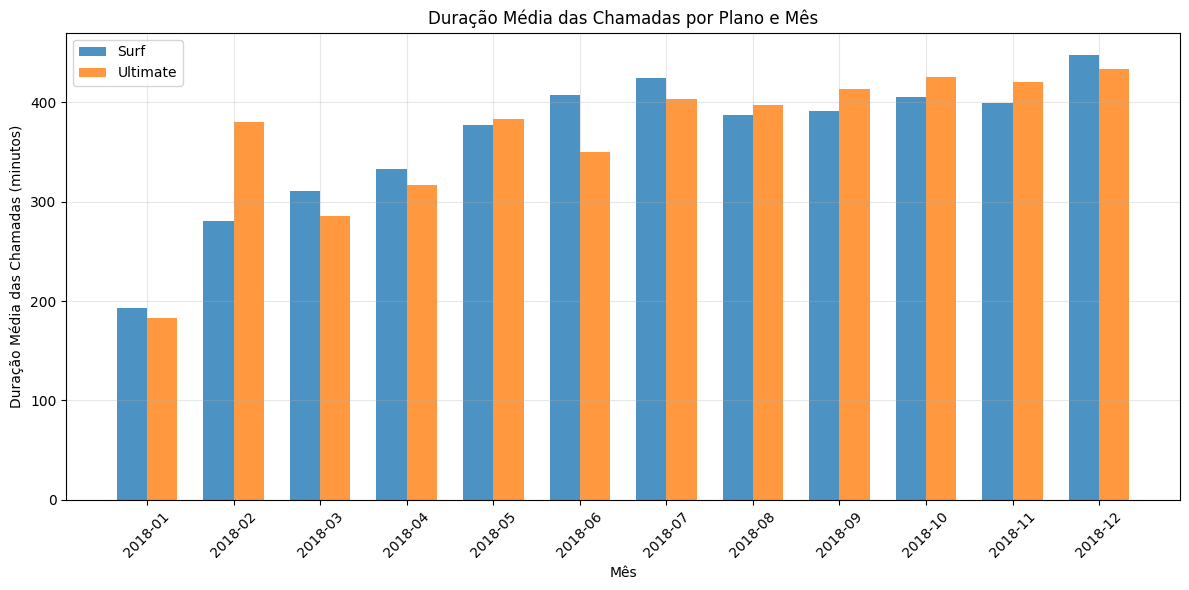

In [180]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
surf_avg_duration = user_behavior[user_behavior['plan']== 'surf'].groupby('month')['duration'].mean()
ultimate_avg_duration = user_behavior[user_behavior['plan']== 'ultimate'].groupby('month')['duration'].mean()
print(surf_avg_duration)
print(ultimate_avg_duration)
# Configurar o gráfico
plt.figure(figsize=(12, 6))

# Obter os meses (índices) - eles devem ser os mesmos para ambos os planos
months = surf_avg_duration.index.astype(str)  # Converter para string para melhor visualização

# Definir posições das barras
x = np.arange(len(months))  # Posições no eixo x
width = 0.35  # Largura das barras

# Criar as barras lado a lado
plt.bar(x - width/2, surf_avg_duration.values, width, label='Surf', alpha=0.8)
plt.bar(x + width/2, ultimate_avg_duration.values, width, label='Ultimate', alpha=0.8)

# Personalizar o gráfico
plt.xlabel('Mês')
plt.ylabel('Duração Média das Chamadas (minutos)')
plt.title('Duração Média das Chamadas por Plano e Mês')
plt.xticks(x, months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

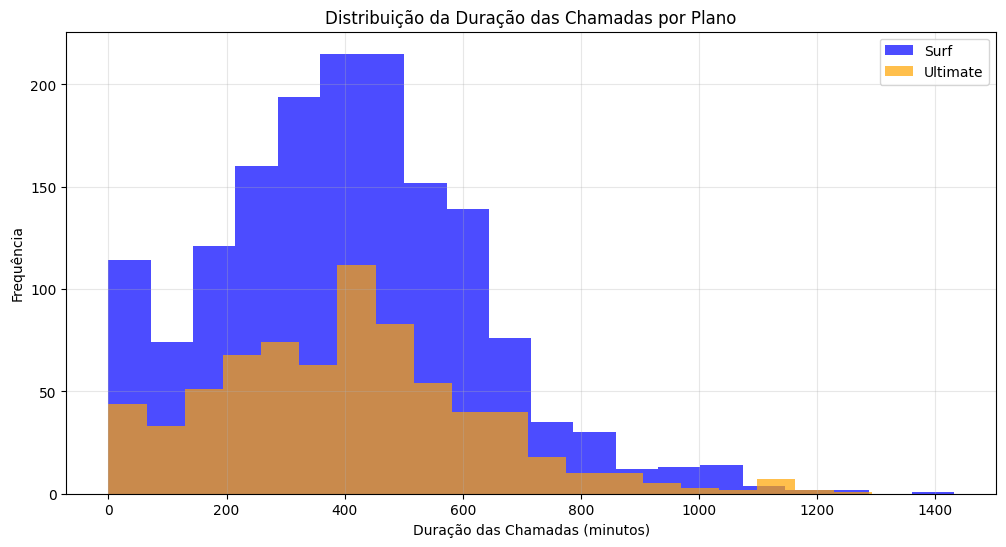

In [181]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
# Histograma da duração das chamadas por plano
plt.figure(figsize=(12, 6))

# Separar os dados por plano
surf_duration = user_behavior[user_behavior['plan'] == 'surf']['duration']
ultimate_duration = user_behavior[user_behavior['plan'] == 'ultimate']['duration']

# Criar histogramas sobrepostos
plt.hist(surf_duration, bins=20, alpha=0.7, label='Surf', color='blue')
plt.hist(ultimate_duration, bins=20, alpha=0.7, label='Ultimate', color='orange')

plt.xlabel('Duração das Chamadas (minutos)')
plt.ylabel('Frequência')
plt.title('Distribuição da Duração das Chamadas por Plano')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [182]:
# Calcule a média e a variância da duração mensal das chamadas
# Para o plano Surf
media_surf = surf_avg_duration.mean()
variancia_surf = surf_avg_duration.var()
# Para o plano Ultimate  
media_ultimate = ultimate_avg_duration.mean()
variancia_ultimate = ultimate_avg_duration.var()
print(f"Surf - Média: {media_surf:.2f} minutos, Variância: {variancia_surf:.2f}")
print(f"Ultimate - Média: {media_ultimate:.2f} minutos, Variância: {variancia_ultimate:.2f}")

Surf - Média: 363.06 minutos, Variância: 5177.32
Ultimate - Média: 365.97 minutos, Variância: 5335.73


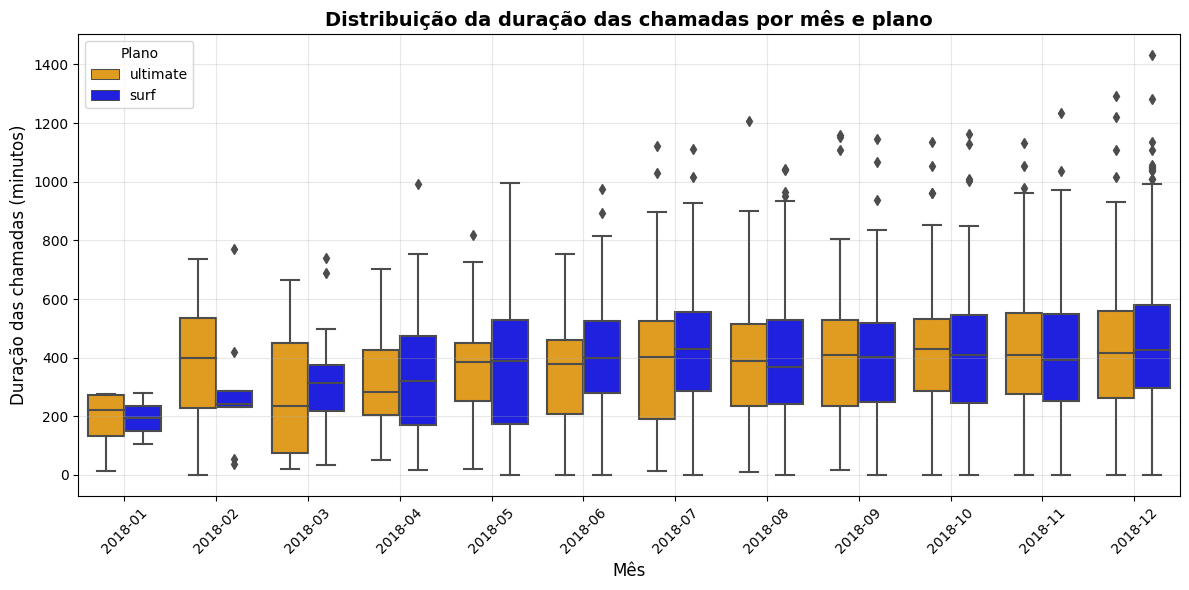

In [183]:
# Definir a ordem cronológica dos meses usando Period
ordem_meses_period = [pd.Period('2018-01'), pd.Period('2018-02'), pd.Period('2018-03'), 
                     pd.Period('2018-04'), pd.Period('2018-05'), pd.Period('2018-06'),
                     pd.Period('2018-07'), pd.Period('2018-08'), pd.Period('2018-09'), 
                     pd.Period('2018-10'), pd.Period('2018-11'), pd.Period('2018-12')]

plt.figure(figsize=(12, 6))
sns.boxplot(data=user_behavior, 
            x='month', 
            y='duration', 
            hue='plan',
            order=ordem_meses_period,
            palette=['orange', 'blue'])

plt.title('Distribuição da duração das chamadas por mês e plano', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Duração das chamadas (minutos)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

    Analisando o comportamento dos usuários através dos dados e das visualizações seja com, gráfico de barras,histograma ou boxplot,podemos concluir que o comportamento dos usuários não varia dependendo do plano. Ao analisarmos a duração média de chamadas mensais de cada plano, podemos ver que o comportamento dos usuários é similar, a exceção seria fevereiro de 2018,onde os usuários do plano ultimate apresentaram um grande aumento na duração das chamadas,comportamento que não foi replicado pelo plano surf,esse aumento pode ter relação com o feriado americano Valentine's Day(Dia dos Namorados), visto que é uma data que comemora a relação entre pessoas e os usuários com bastante tempo limite, podem ter utilizado mais tempo. Outra hipótese válda é que usuários que estão em relacionamentos à distância, por precisarem se comunicar mais, tenham optado pelo plano Ultimate e o Valentine's Day seria um reflexo da população do plano. A sobreposição dos histogramas mostra claramente que a frequência da duração das chamadas são quase que espelhadas proporcionalmente, onde o plano Surf, por ter mais assinaturas,apresenta a mesma distribuição com mais frequência. Por fim, a utilização do boxplot evidência que a mediana nos 2 planos é bastante próxima dos 400, e essa semellhança pode ser analisada em qualquer outro ponto estatístico posicional, como o espaço interquartil e os limites de bigodes inferior e superior.

### Mensagens

In [184]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
surf_avg_msg = user_behavior[user_behavior['plan']== 'surf'].groupby('month')['messages_count'].mean()
ultimate_avg_msg = user_behavior[user_behavior['plan']== 'ultimate'].groupby('month')['messages_count'].mean()
print(surf_avg_msg)
print(ultimate_avg_msg)

month
2018-01    10.500000
2018-02    12.000000
2018-03    15.260870
2018-04    17.400000
2018-05    24.012987
2018-06    25.298969
2018-07    27.033058
2018-08    28.777778
2018-09    30.762887
2018-10    33.839662
2018-11    32.385159
2018-12    38.600629
Freq: M, Name: messages_count, dtype: float64
month
2018-01    15.500000
2018-02    21.571429
2018-03    20.250000
2018-04    22.047619
2018-05    32.103448
2018-06    29.340426
2018-07    32.830508
2018-08    38.478873
2018-09    37.895349
2018-10    39.443396
2018-11    38.606299
2018-12    45.006623
Freq: M, Name: messages_count, dtype: float64


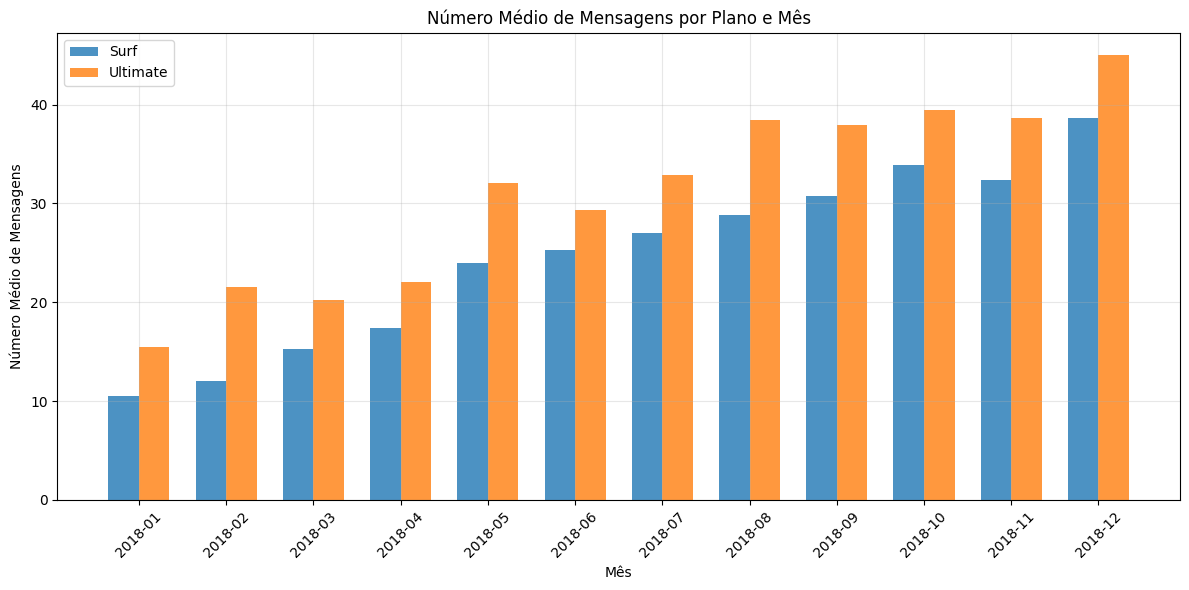

In [185]:
# Configurar o gráfico de barras
plt.figure(figsize=(12, 6))

# Obter os meses (índices) - eles devem ser os mesmos para ambos os planos
months = surf_avg_msg.index.astype(str)  # Converter para string para melhor visualização

# Definir posições das barras
x = np.arange(len(months))  # Posições no eixo x
width = 0.35  # Largura das barras

# Criar as barras lado a lado
plt.bar(x - width/2, surf_avg_msg.values, width, label='Surf', alpha=0.8)
plt.bar(x + width/2, ultimate_avg_msg.values, width, label='Ultimate', alpha=0.8)

# Personalizar o gráfico
plt.xlabel('Mês')
plt.ylabel('Número Médio de Mensagens')
plt.title('Número Médio de Mensagens por Plano e Mês')
plt.xticks(x, months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

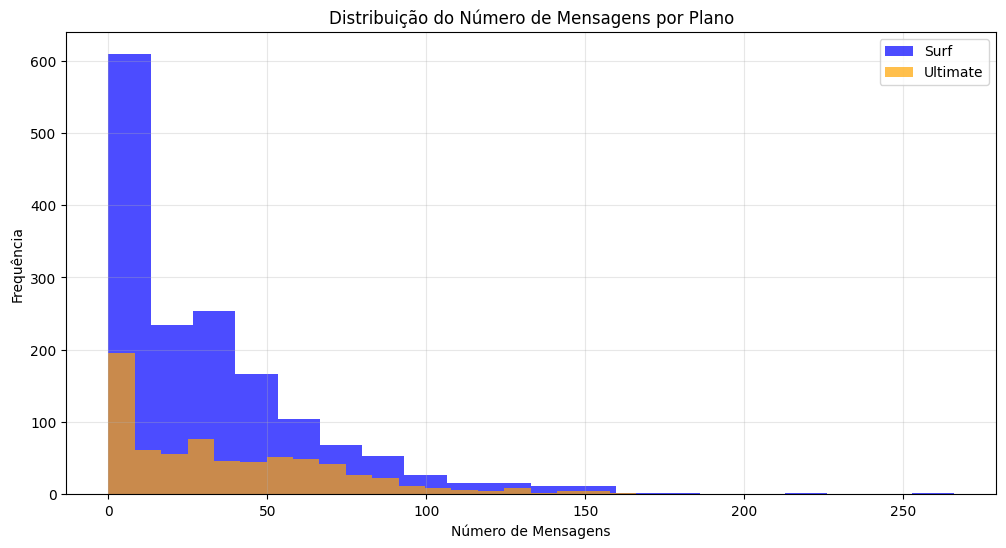

In [186]:
# Histograma do número de mensagens por plano
plt.figure(figsize=(12, 6))

# Separar os dados por plano
surf_messages = user_behavior[user_behavior['plan'] == 'surf']['messages_count']
ultimate_messages = user_behavior[user_behavior['plan'] == 'ultimate']['messages_count']

# Criar histogramas sobrepostos
plt.hist(surf_messages, bins=20, alpha=0.7, label='Surf', color='blue')
plt.hist(ultimate_messages, bins=20, alpha=0.7, label='Ultimate', color='orange')

plt.xlabel('Número de Mensagens')
plt.ylabel('Frequência')
plt.title('Distribuição do Número de Mensagens por Plano')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [187]:
# Calcule a média e a variância do número mensal de mensagens
# Para o plano Surf
media_surf_msg = surf_avg_msg.mean()
variancia_surf_msg = surf_avg_msg.var()

# Para o plano Ultimate
media_ultimate_msg = ultimate_avg_msg.mean()
variancia_ultimate_msg = ultimate_avg_msg.var()

print(f"Mensagens - Surf - Média: {media_surf_msg:.2f} mensagens, Variância: {variancia_surf_msg:.2f}")
print(f"Mensagens - Ultimate - Média: {media_ultimate_msg:.2f} mensagens, Variância: {variancia_ultimate_msg:.2f}")

Mensagens - Surf - Média: 24.66 mensagens, Variância: 81.89
Mensagens - Ultimate - Média: 31.09 mensagens, Variância: 87.35


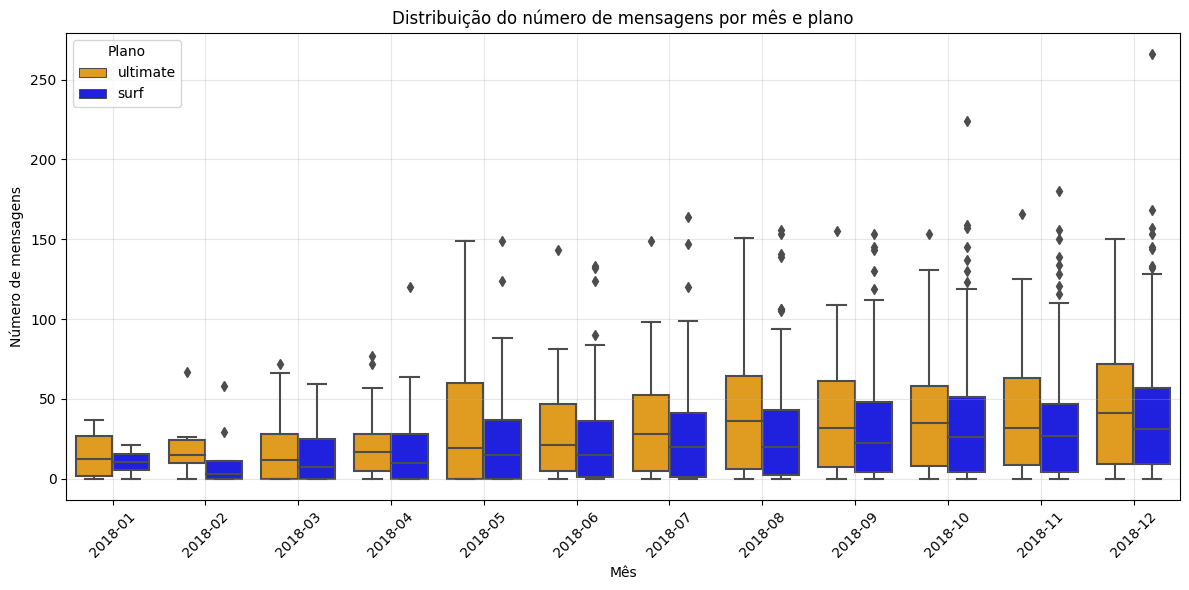

In [188]:
# Boxplot da duração das chamadas por mês e plano
plt.figure(figsize=(12, 6))
sns.boxplot(data=user_behavior, 
            x='month', 
            y='messages_count',
            hue='plan',
            order=ordem_meses_period,
            palette=['orange', 'blue'])

plt.title('Distribuição do número de mensagens por mês e plano')
plt.xlabel('Mês')
plt.ylabel('Número de mensagens')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

    Comparando os dados de Mensagens que os usuários de cada plano costumam enviar por mês, podemos perceber que a grande maioria dos usuários utiliza poucas mensagens de texto,e os planos apresentam um comportamento parecido, os usuários do plano Ultimate tendem a mandar mais mensagens,provavelmente porque o pacote permite, mas a relação de mensagens por mês é parecida com a de envios de usuários com o plano Surf. Novamente, a exceção é o mês de fevereiro de 2018. Vale destacar que a média de mensagens por mês dos usuários é bem menor que o limite do plano Surf,mesmo para usuários que optam pelo plano Ultimate. Essa análise indica que o motivo para os usuários estarem optando pelo plano Ultimate não é o aumento do número de mensagens de texto. O fato de existirem diversos outliers no plano Surf,valores acima do bigode superior, indica mais uma vez, que mesmo usuários que abusam de mensagens de texto não aderem ao plano com maior limite de mensagens. Isso pode ocorrer pois o limite de 1000 é muito distante até do valor máximo de mensagens por mês que seria um pouco maior que 250 mensagens, essa distância pode criar a sensação que usuário está pagando por 1000 mensagens, e eles sabem que não utilizaram nada perto desse limite.

### Internet

In [189]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
surf_avg_internet = user_behavior[user_behavior['plan']== 'surf'].groupby('month')['gb_used'].mean()
ultimate_avg_internet = user_behavior[user_behavior['plan']== 'ultimate'].groupby('month')['gb_used'].mean()
print(surf_avg_internet)
print(ultimate_avg_internet)

month
2018-01     4.760605
2018-02    11.893402
2018-03    13.032656
2018-04    11.703323
2018-05    13.609722
2018-06    14.942900
2018-07    16.390235
2018-08    16.401691
2018-09    16.202570
2018-10    16.905601
2018-11    15.956303
2018-12    17.707490
Freq: M, Name: gb_used, dtype: float64
month
2018-01     6.755950
2018-02    16.727352
2018-03    17.892108
2018-04    15.743803
2018-05    16.234846
2018-06    14.978439
2018-07    15.961664
2018-08    17.397188
2018-09    16.572138
2018-10    17.199759
2018-11    16.634458
2018-12    17.893742
Freq: M, Name: gb_used, dtype: float64


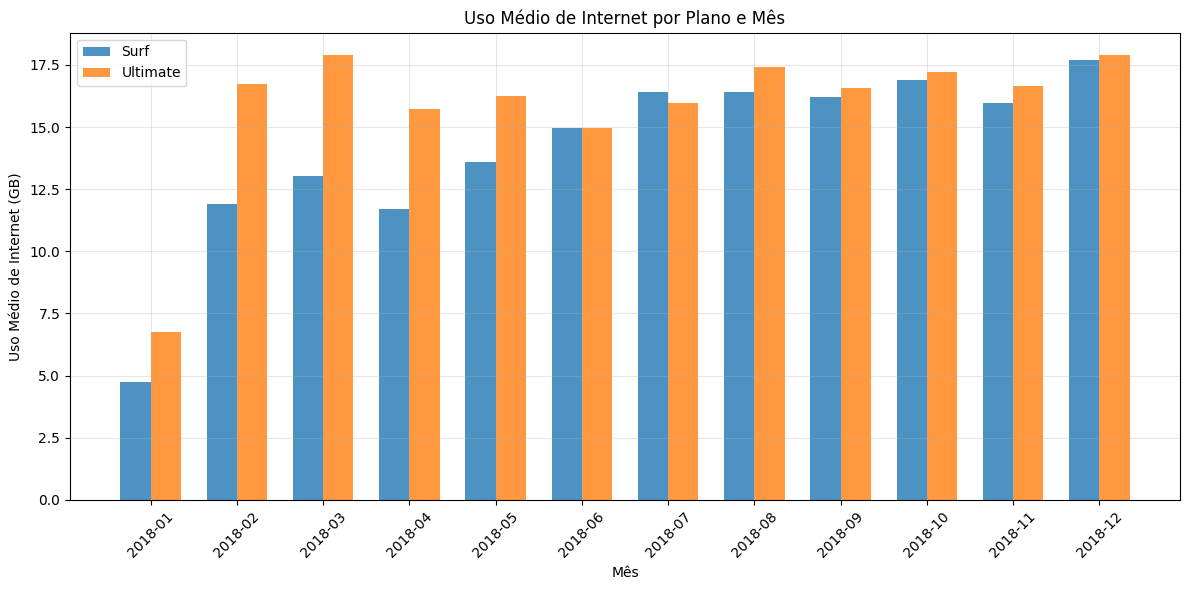

In [190]:
# Configurar o gráfico de barras
plt.figure(figsize=(12, 6))

# Obter os meses (índices) - eles devem ser os mesmos para ambos os planos
months = surf_avg_internet.index.astype(str)  # Converter para string para melhor visualização

# Definir posições das barras
x = np.arange(len(months))  # Posições no eixo x
width = 0.35  # Largura das barras

# Criar as barras lado a lado
plt.bar(x - width/2, surf_avg_internet.values, width, label='Surf', alpha=0.8)
plt.bar(x + width/2, ultimate_avg_internet.values, width, label='Ultimate', alpha=0.8)

# Personalizar o gráfico
plt.xlabel('Mês')
plt.ylabel('Uso Médio de Internet (GB)')
plt.title('Uso Médio de Internet por Plano e Mês')
plt.xticks(x, months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

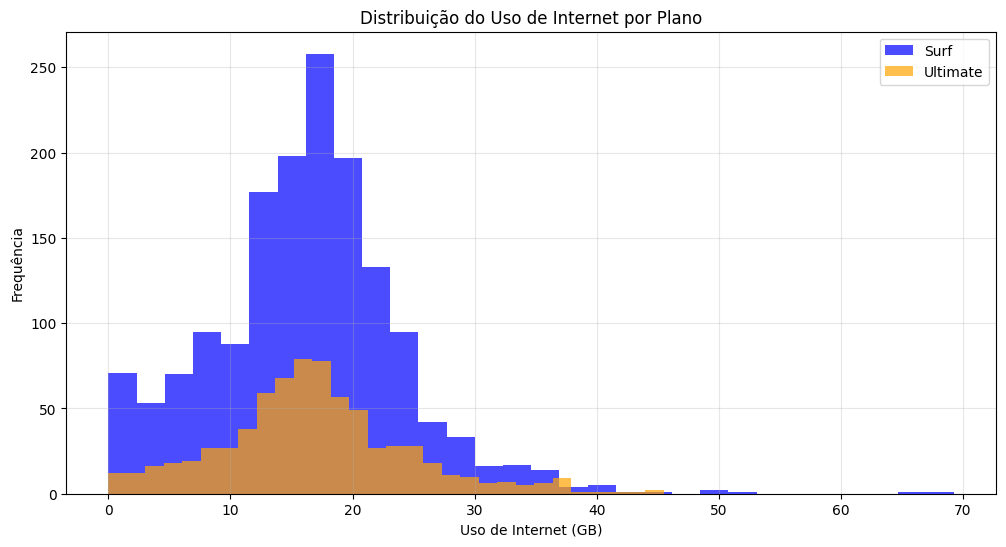

In [191]:
# Histograma do uso de internet por plano
plt.figure(figsize=(12, 6))

# Separar os dados por plano
surf_internet = user_behavior[user_behavior['plan'] == 'surf']['gb_used']
ultimate_internet = user_behavior[user_behavior['plan'] == 'ultimate']['gb_used']

# Criar histogramas sobrepostos
plt.hist(surf_internet, bins=30, alpha=0.7, label='Surf', color='blue')
plt.hist(ultimate_internet, bins=30, alpha=0.7, label='Ultimate', color='orange')

plt.xlabel('Uso de Internet (GB)')
plt.ylabel('Frequência')
plt.title('Distribuição do Uso de Internet por Plano')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [192]:
# Calcule a média e a variância do uso mensal de internet
# Para o plano Surf
media_surf_internet = surf_avg_internet.mean()
variancia_surf_internet = surf_avg_internet.var()

# Para o plano Ultimate
media_ultimate_internet = ultimate_avg_internet.mean()
variancia_ultimate_internet = ultimate_avg_internet.var()

print(f"Internet - Surf - Média: {media_surf_internet:.2f} MB, Variância: {variancia_surf_internet:.2f}")
print(f"Internet - Ultimate - Média: {media_ultimate_internet:.2f} MB, Variância: {variancia_ultimate_internet:.2f}")

Internet - Surf - Média: 14.13 MB, Variância: 12.66
Internet - Ultimate - Média: 15.83 MB, Variância: 8.92


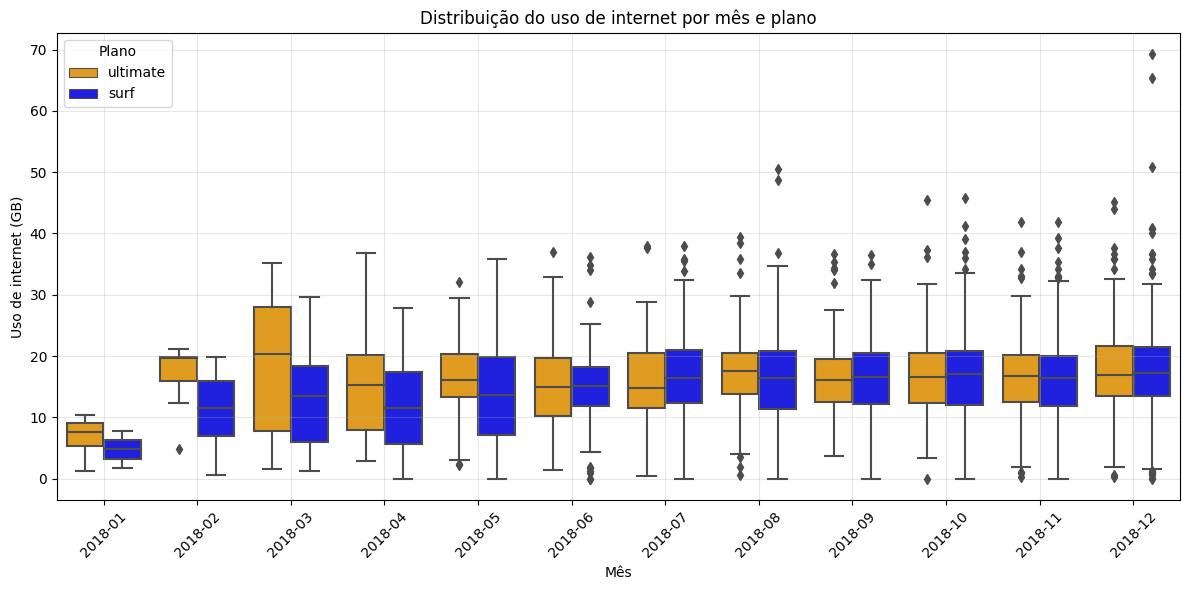

In [193]:
# Diagrama de caixa para visualizar a distribuição do uso de internet
plt.figure(figsize=(12, 6))
sns.boxplot(data=user_behavior,
            x='month',
            y='gb_used',
            hue='plan',
            order=ordem_meses_period,
            palette=['orange', 'blue'])
plt.title('Distribuição do uso de internet por mês e plano')
plt.xlabel('Mês')
plt.ylabel('Uso de internet (GB)')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

    Quanto ao uso de dados, o consumo de internet sugere que,usuários do plano Ultimate começaram o ano de 2018 com uso médio de internet mais alto, o uso médio atingiu seu pico em Março,e continuou superior ao plano surf até maio. A partir de Junho o consumo médio entre os usuários dos diferentes planos entrou em equilíbrio, o uso médio do plano Surf,que começou menor no ano de 2018, aumentou gradualmente,em colaboração com a queda do consumo médio dos usuários do plano Ultimate, gerou esse equilíbrio. Ao analisarmos o histograma, podemos ver que os usuários tem comportamentos parecidos,independentemente do plano, com uma distribuição que lembra a normal, e maior frequência entre os 10 a 20GB usados. Essa relação entre os usuários dos diferentes planos utilizarem a mesma quantidade de MB indica que o uso de internet, possivelmente, não é o motivo pelo qual usuários adotam o plano Ultimate. Essa conclusão é reforçada mais uma vez no boxplot,onde podemos ver as medianas,espaços interquartis e bigode inferior parecidos,com os maiores usos,no plano Surf,que não só tem os usuários que mais utilizaram internet(pontos mais altos),como mais outliers superiores e um bigode superior mais alto que o plano Ultimate. Baseado nas análises apresentadas é possivel concluir que os usuários não observam a taxa excedente de internet como algo relevante, o que não justifica a assinatura no plano mais caro que fornece um limite maior de dados.

## Receita

In [194]:
# Comparando a receita mensal dos usuários por plano
surf_avg_tot = user_behavior[user_behavior['plan']== 'surf'].groupby('month')['monthly_total'].mean()
ultimate_avg_tot = user_behavior[user_behavior['plan']== 'ultimate'].groupby('month')['monthly_total'].mean()
print(surf_avg_tot)
print(ultimate_avg_tot)

month
2018-01    20.000000
2018-02    34.256733
2018-03    45.790261
2018-04    40.454700
2018-05    47.235155
2018-06    48.930735
2018-07    62.221942
2018-08    63.572562
2018-09    57.948540
2018-10    65.046710
2018-11    57.628813
2018-12    70.102687
Freq: M, Name: monthly_total, dtype: float64
month
2018-01    70.000000
2018-02    70.000000
2018-03    74.666667
2018-04    73.000000
2018-05    70.724138
2018-06    71.638298
2018-07    71.898305
2018-08    72.859155
2018-09    72.034884
2018-10    72.311321
2018-11    71.708661
2018-12    73.291391
Freq: M, Name: monthly_total, dtype: float64


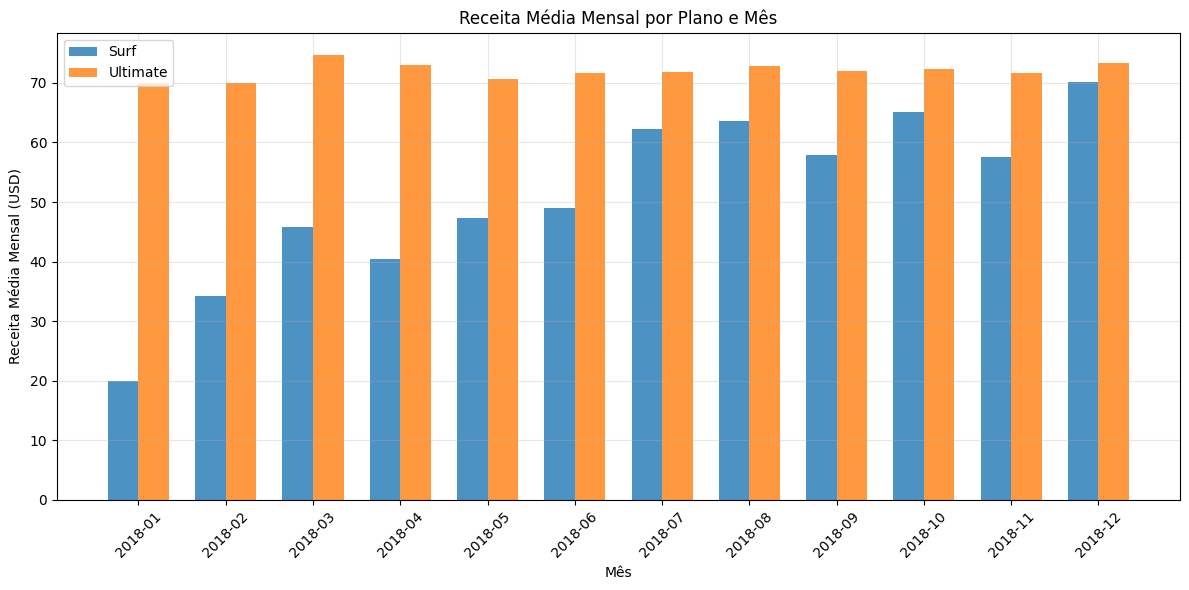

In [195]:
# Configurar o gráfico de barras
plt.figure(figsize=(12, 6))

# Obter os meses (índices) - eles devem ser os mesmos para ambos os planos
months = surf_avg_tot.index.astype(str)  # Converter para string para melhor visualização

# Definir posições das barras
x = np.arange(len(months))  # Posições no eixo x
width = 0.35  # Largura das barras

# Criar as barras lado a lado
plt.bar(x - width/2, surf_avg_tot.values, width, label='Surf', alpha=0.8)
plt.bar(x + width/2, ultimate_avg_tot.values, width, label='Ultimate', alpha=0.8)

# Personalizar o gráfico
plt.xlabel('Mês')
plt.ylabel('Receita Média Mensal (USD)')
plt.title('Receita Média Mensal por Plano e Mês')
plt.xticks(x, months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

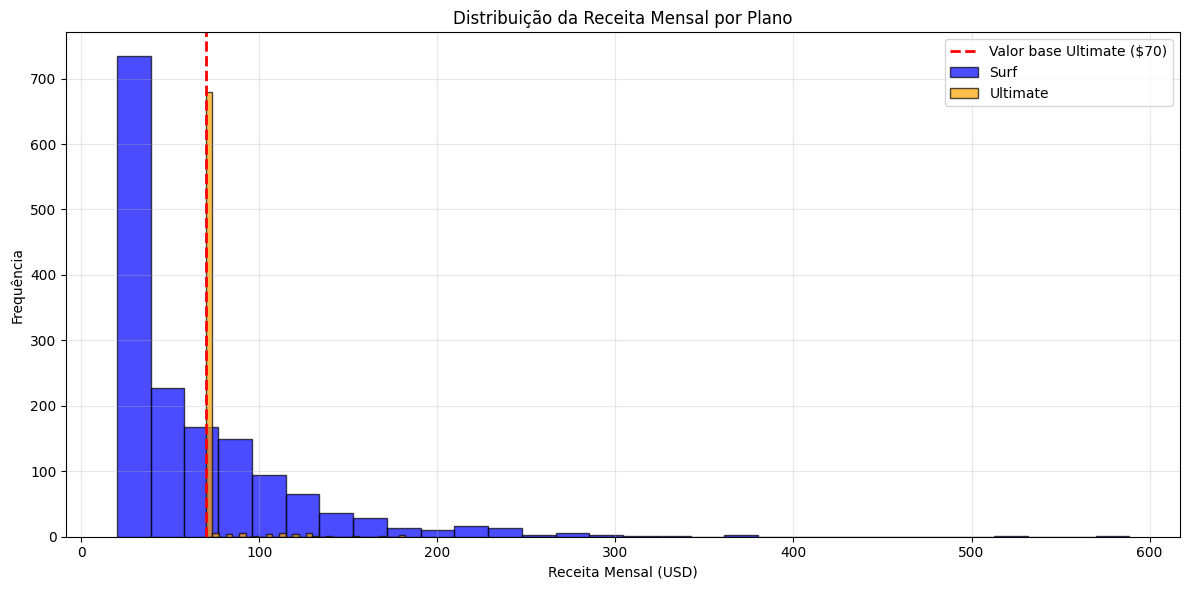

In [196]:
# Histograma da receita mensal por plano com linha de referência
plt.figure(figsize=(12, 6))

# Separar os dados de receita por plano
surf_receitas = user_behavior[user_behavior['plan'] == 'surf']['monthly_total']
ultimate_receitas = user_behavior[user_behavior['plan'] == 'ultimate']['monthly_total']

# Criar histogramas sobrepostos
plt.hist(surf_receitas, bins=30, alpha=0.7, label='Surf', color='blue', edgecolor='black')
plt.hist(ultimate_receitas, bins=30, alpha=0.7, label='Ultimate', color='orange', edgecolor='black')

# Adicionar linha vertical no valor 70
plt.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Valor base Ultimate ($70)')

# Personalizar o gráfico
plt.xlabel('Receita Mensal (USD)')
plt.ylabel('Frequência')
plt.title('Distribuição da Receita Mensal por Plano')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

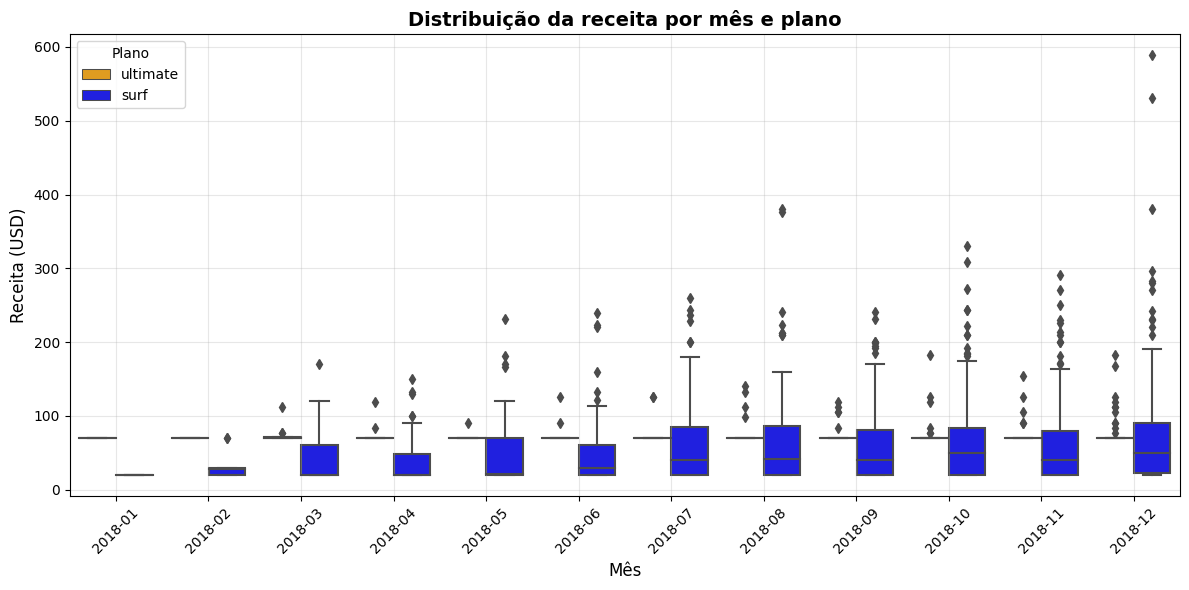

In [197]:
# Boxplot da receita por mês e plano
plt.figure(figsize=(12, 6))
sns.boxplot(data=user_behavior,
            x='month',
            y='monthly_total',
            hue='plan',
            order=ordem_meses_period,
            palette=['orange', 'blue'])
plt.title('Distribuição da receita por mês e plano', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [198]:
# Estatísticas descritivas da receita
print("=== ESTATÍSTICAS DA RECEITA ===")
print(f"Surf - Média: ${surf_receitas.mean():.2f}")
print(f"Surf - Mediana: ${surf_receitas.median():.2f}")
print(f"Surf - Desvio Padrão: ${surf_receitas.std():.2f}")
print(f"Surf - Valor Máximo: ${surf_receitas.max():.2f}")
print()
print(f"Ultimate - Média: ${ultimate_receitas.mean():.2f}")
print(f"Ultimate - Mediana: ${ultimate_receitas.median():.2f}")
print(f"Ultimate - Desvio Padrão: ${ultimate_receitas.std():.2f}")

=== ESTATÍSTICAS DA RECEITA ===
Surf - Média: $60.33
Surf - Mediana: $40.15
Surf - Desvio Padrão: $55.26
Surf - Valor Máximo: $588.64

Ultimate - Média: $72.31
Ultimate - Mediana: $70.00
Ultimate - Desvio Padrão: $11.40


    Analisando os dados sobre a receita podemos verificar que, ao longo do ano, a média de receita mensal derivada do plano Surf aumentou, com a receita sendo o valor do plano em janeiro (USD 20) e atingindo o valor máximo de USD 70 em Dezembro. O valor médio do plano Surf no final do ano chegou ao valor do Plano Ultimate, que teve a receita média constante durante o ano, isso indica que os usuários do plano Surf começaram a optar pelas taxas adicionais. 

    Analisando o histograma de frequência de gastos, vemos uma discrepância com todos os histogramas anteriores. As frequências do plano Surf apresentam um gráfico de assimetria à direita, indicando que a maior frequência de usuários se encontram próxima ao valor mínimo do plano (USD 20), se estendendo até um valor máximo de USD 588.64. 

    O comportamento das demais estatísticas ainda mostram grande variabilidade nas receitas, com desvio padrão de USD 55.26, média de USD 60.33, mais que o triplo do valor original, e mediana de USD 40.15, ou seja, mais da metade dos assinantes do plano Surf pagam mais em taxas adicionais que o incluído no pacote original. 

    Essa descoberta fica ainda mais surpreendente quando comparamos com as estatísticas do plano Ultimate, que como dito anteriormente, não alterou durante o ano, tem uma distribuição baixíssima, com desvio padrão de apenas USD 11.40, onde a média (USD 72.31) e a mediana (USD 70) estão próximas do valor original do plano (USD 70), sua frequência se concentra um pouco acima dos USD 70 e seu suposto boxplot é basicamente a faixa da mediana quando em escala com o plano Surf.

    Essas descobertas sugerem que possíveis ações para aumentar o lucro da empresa podem incluir:

    Reavaliação dos valores inclusos e adicionais no plano Surf

- Reavaliar os limites dos planos pré-pagos, pois os pacotes da Megaline não estão condizentes com o interesse dos clientes, como visto nas avaliações dos dados, principalmente, de mensagens de texto

- Uma ferramenta de auxílio ao cliente, indicando como seus gastos anteriores encaixam com diferentes planos para sugestão de planos mais alinhados com seu consumo. Essa sugestão é resultado de clientes do plano Surf pagarem muito mais em taxas adicionais, como o caso máximo de USD 588.64, média de triplicar o valor e mediana indicando pelo menos a dobra do valor original

- Adição de um novo plano, entre o Surf e o Ultimate, com intuito de melhor atender a utilização dos clientes

## Testes de hipótese

### Formulação das Hipóteses
Hipótese Nula (H₀): A receita média dos usuários do plano Surf é igual à receita média dos usuários do plano Ultimate

Hipótese Alternativa (H₁): A receita média dos usuários do plano Surf é diferente da receita média dos usuários do plano Ultimate

In [199]:
# Teste as hipóteses

# Definir o nível de significância
alpha = 0.05

# Realizar o teste t de Student para amostras independentes
results = st.ttest_ind(surf_receitas, ultimate_receitas)
p_value = results.pvalue
statistic = results.statistic

print("=== TESTE DE HIPÓTESE: RECEITA MÉDIA DOS PLANOS ===")
print(f"Hipótese Nula (H₀): mu_surf = mu_ultimate")
print(f"Hipótese Alternativa (H₁): mu_surf != mu_ultimate")
print(f"Nível de significância (alpha): {alpha}")
print()
print(f"Estatística do teste: {statistic:.4f}")
print(f"Valor p: {p_value:.6f}")
print()

# Interpretação do resultado
if p_value < alpha:
    print(f"Resultado: Rejeitamos H₀ (p-value = {p_value:.6f} < alpha = {alpha})")
    print("Conclusão: Existe diferença significativa entre as receitas médias dos planos")
else:
    print(f"Resultado: Não rejeitamos H₀ (p-value = {p_value:.6f} ≥ alpha = {alpha})")
    print("Conclusão: Não há evidência de diferença significativa entre as receitas médias")

print()
print("=== ESTATÍSTICAS DESCRITIVAS ===")
print(f"Receita média Surf: USD {surf_receitas.mean():.2f}")
print(f"Receita média Ultimate: USD {ultimate_receitas.mean():.2f}")
print(f"Diferença: USD {ultimate_receitas.mean() - surf_receitas.mean():.2f}")

=== TESTE DE HIPÓTESE: RECEITA MÉDIA DOS PLANOS ===
Hipótese Nula (H₀): mu_surf = mu_ultimate
Hipótese Alternativa (H₁): mu_surf != mu_ultimate
Nível de significância (alpha): 0.05

Estatística do teste: -5.7636
Valor p: 0.000000

Resultado: Rejeitamos H₀ (p-value = 0.000000 < alpha = 0.05)
Conclusão: Existe diferença significativa entre as receitas médias dos planos

=== ESTATÍSTICAS DESCRITIVAS ===
Receita média Surf: USD 60.33
Receita média Ultimate: USD 72.31
Diferença: USD 11.99


### Fórmulação de Hipótese:
Hipótese Nula (H₀):  A receita média dos usuários da região de NY-NJ não difere das demais regiões.

Hipótese Alternativa (H₁): A receita média dos usuários da área de NY-NJ difere das demais regiões.

In [200]:
# Teste as hipóteses
# Separar as receitas dos usuários de NY-NJ
user_behavior = user_behavior.merge(users[['user_id','city']], on=['user_id'], how='left')
ny_nj_users = user_behavior[user_behavior['city'].str.contains('NY|NJ', na=False)]

# Separar as receitas dos usuários de regiões não NY|NJ
other_users = user_behavior[~user_behavior['city'].str.contains('NY|NJ', na=False)]

# Extrair as receitas de cada grupo
ny_nj_receitas = ny_nj_users['monthly_total']
other_receitas = other_users['monthly_total']

# Definir o nível de significância
alpha = 0.05

# Aplicar o teste t de Student
results = st.ttest_ind(ny_nj_receitas, other_receitas)
p_value = results.pvalue
statistic = results.statistic

print("=== TESTE DE HIPÓTESE: RECEITA MÉDIA NY-NJ vs OUTRAS REGIÕES ===")
print(f"Hipótese Nula (H₀): mu_nynj = mu_outras")
print(f"Hipótese Alternativa (H₁): mu_nynj != mu_outras")
print(f"Nível de significância (alpha): {alpha}")
print()
print(f"Estatística do teste: {statistic:.4f}")
print(f"Valor p: {p_value:.6f}")
print()

# Interpretação do resultado
if p_value < alpha:
    print(f"Resultado: Rejeitamos H₀ (p-value = {p_value:.6f} < alpha = {alpha})")
    print("Conclusão: Existe diferença significativa entre as receitas médias das regiões")
else:
    print(f"Resultado: Não rejeitamos H₀ (p-value = {p_value:.6f} ≥ alpha = {alpha})")
    print("Conclusão: Não há evidência de diferença significativa entre as receitas médias")

print()
print("=== ESTATÍSTICAS DESCRITIVAS ===")
print(f"Receita média NY-NJ: USD {ny_nj_receitas.mean():.2f}")
print(f"Receita média outras regiões: USD {other_receitas.mean():.2f}")
print(f"Diferença: USD {ny_nj_receitas.mean() - other_receitas.mean():.2f}")

=== TESTE DE HIPÓTESE: RECEITA MÉDIA NY-NJ vs OUTRAS REGIÕES ===
Hipótese Nula (H₀): mu_nynj = mu_outras
Hipótese Alternativa (H₁): mu_nynj != mu_outras
Nível de significância (alpha): 0.05

Estatística do teste: -1.6093
Valor p: 0.107688

Resultado: Não rejeitamos H₀ (p-value = 0.107688 ≥ alpha = 0.05)
Conclusão: Não há evidência de diferença significativa entre as receitas médias

=== ESTATÍSTICAS DESCRITIVAS ===
Receita média NY-NJ: USD 61.08
Receita média outras regiões: USD 64.90
Diferença: USD -3.82


## Conclusão geral


Objetivo: Determinar qual plano pré-pago da Megaline (Surf ou Ultimate) gera mais receita para orientar o orçamento de publicidade, baseado em dados de 500 clientes durante 2018.

   Processamento e Padronização de Dados
- Ajustes de Tipagem: Identificadores (user_id) foram convertidos de inteiro para string e colunas de data para o formato datetime.
- Valores Financeiros: Colunas de custos foram ajustadas para float para garantir precisão decimal em cálculos de receita.
- Unificação de Unidades: O consumo de internet foi padronizado em megabytes (MB) para alinhar os planos aos custos excedentes.

    Análise do Comportamento do Usuário
- Perfil de Consumo: Os usuários de ambos os planos apresentam padrões similares em chamadas, mensagens e dados.
- Subutilização de SMS: O limite de mensagens é muito superior à necessidade real, indicando que este não é o diferencial para o plano Ultimate.Usuários consomem em média apenas 25-31 mensagens vs limite de 50-1000
- Resiliência ao Excedente: Usuários do plano Surf frequentemente pagam taxas extras elevadas sem migrar para o plano Ultimate.

    Desempenho Financeiro e Hipóteses
- Lucratividade: O plano Surf gera alta receita excedente 60,33USD (média de triplo do valor original) e tem receita média 200% maior que o valor base, como indica a mediana de USD 40,15 enquanto o Ultimate permanece estável.
- Testes Estatísticos: Confirmou-se diferença significativa entre as receitas dos planos Surf e Ultimate. Não houve evidência de que a região (NY-NJ) influencie a receita média.

    Recomendações Estratégicas
- Ajuste de Produto: Criação de um plano intermediário entre USD20-70 e redução dos limites de SMS do plano Ultimate de 1000 para 200.
- Retenção: Implementação de ferramentas de sugestão de plano ideal baseadas no histórico de consumo do cliente.
